### Before you execute the notebook please run: 
#### 01_sync_data.py to download the audio files from azure
#### 02_extract_features.py to splitting the files and for feature extraction and augmentation

# Importing

In [1]:
import sys
sys.path.append('src')
import io
import os
import pickle
import time
import warnings
import librosa
import numpy as np
import pandas as pd
import tensorflow as tf
!pip install azure-storage-blob
!pip install seaborn python-dotenv librosa scikit-learn
from azure.storage.blob import BlobServiceClient
from dotenv import load_dotenv
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau,
)
import tensorflow.keras.layers as L
from src.audio_pipeline import extract_features_from_audio_array, get_feature_names
from src.config import (
    ASSETS_DIR,
    ENCODER_PATH,
    MODEL_PATH,
    MONO,
    N_FEATURES, 
    SCALER_PATH,
    TARGET_SR,
)
from src.manifest_builder import (
    add_augmented_rows,
    assign_splits,
    build_manifest,
    save_manifest,
    validate_manifest,
)
from src.speaker_splitter import add_speaker_column, speaker_split

warnings.filterwarnings("ignore")
load_dotenv()


True

# Integration with Azure

In [2]:
import sys
sys.path.append('src')
from azure.storage.blob import BlobServiceClient
import pandas as pd
import os
from dotenv import load_dotenv
import numpy as np
import io
import librosa


load_dotenv()

CONTAINER_NAME = "wav-files"

connection_string = os.getenv("AZURE_STORAGE_CONNECTION_STRING")

if not connection_string:
    raise ValueError("AZURE_STORAGE_CONNECTION_STRING not set")

blob_service = BlobServiceClient.from_connection_string(connection_string)
container_client = blob_service.get_container_client(CONTAINER_NAME)


def get_df_from_blob_dataset(prefix):
    emotions = []
    file_paths = []

    for blob in container_client.list_blobs(name_starts_with=prefix):
        if blob.name.endswith(".wav"):
            filename = blob.name.split("/")[-1]
            parts = filename.split("-")

            if len(parts) >= 3:
                emotion = parts[2].lower()
            else:
                emotion = "unknown"

            emotions.append(emotion)
            file_paths.append(blob.name)

    return pd.DataFrame({
        "Path": file_paths,
        "Emotions": emotions
    })


def load_audio_from_blob(blob_service, blob_path: str) -> tuple[np.ndarray, int]:
    clean_path = blob_path.replace("\\", "/")
    blob_client = blob_service.get_blob_client(container=CONTAINER_NAME, blob=clean_path)
    audio_file = io.BytesIO(blob_client.download_blob().readall())
    data, sr = librosa.load(audio_file, sr=TARGET_SR, mono=MONO)
    return data.astype(np.float32), sr


ravdess_df = get_df_from_blob_dataset("RAVDESS/")
crema_df   = get_df_from_blob_dataset("CREMAD/")
tess_df    = get_df_from_blob_dataset("TESS/")
savee_df   = get_df_from_blob_dataset("SAVEE/")
asvp_df    = get_df_from_blob_dataset("ASVP-ESD/")  

data_path = pd.concat(
    [ravdess_df, crema_df, tess_df, savee_df, asvp_df],  
    axis=0
).reset_index(drop=True)

os.makedirs("data/csv", exist_ok=True)
data_path.to_csv("data/csv/data_path.csv", index=False)

print("Total files:", len(data_path))
print(data_path.head())
print("\nEmotion distribution:")
print(data_path["Emotions"].value_counts())


Total files: 8515
                                           Path Emotions
0  RAVDESS/Actor_01/RAVDESS-01-Angry-1-dup0.wav    angry
1  RAVDESS/Actor_01/RAVDESS-01-Angry-1-dup1.wav    angry
2  RAVDESS/Actor_01/RAVDESS-01-Angry-1-dup2.wav    angry
3  RAVDESS/Actor_01/RAVDESS-01-Angry-1-dup3.wav    angry
4  RAVDESS/Actor_01/RAVDESS-01-Angry-2-dup0.wav    angry

Emotion distribution:
Emotions
angry      2190
neutral    2180
happy      2118
sad        2027
Name: count, dtype: int64


# EDA

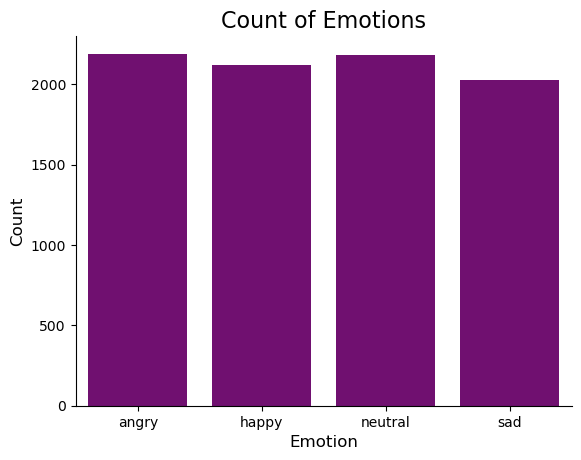

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.countplot(
    x=data_path["Emotions"],  
    color="purple"             
)
plt.title('Count of Emotions', size=16)
plt.xlabel('Emotion', size=12)
plt.ylabel('Count', size=12)

sns.despine(top=True, right=True, left=False, bottom=False)

plt.show()

# Data Augmentation Functions

In [4]:

def noise(data, sr=None):
    noise_amp = 0.035 * np.random.uniform() * np.max(np.abs(data))
    return data + noise_amp * np.random.normal(size=data.shape[0])


def stretch(data, sr=None, rate=0.8):
    return librosa.effects.time_stretch(y=data, rate=rate)


def shift(data, sr=None):
    shift_range = int(np.random.uniform(-5, 5) * 1000)
    return np.roll(data, shift_range)


def pitch(data, sr, n_steps=0.7):
    return librosa.effects.pitch_shift(y=data, sr=sr, n_steps=n_steps)


AUGMENTATIONS = {
    "noise":   lambda d, sr: noise(d, sr),
    "stretch": lambda d, sr: stretch(d, sr),
    "shift":   lambda d, sr: shift(d, sr),
    "pitch":   lambda d, sr: pitch(d, sr),
}

# Data Preparation (Scaling & Encoding)

In [5]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

train_df2 = pd.read_csv("data/csv/train_features_ready_for_model.csv")
val_df2   = pd.read_csv("data/csv/val_features_ready_for_model.csv")
test_df2  = pd.read_csv("data/csv/test_features_ready_for_model.csv")

# Load (128, 128) spectrograms from .npy files
X_train = np.stack([np.load(p) for p in train_df2["npy_path"]])  # (N, 128, 128)
X_val   = np.stack([np.load(p) for p in val_df2["npy_path"]])
X_test  = np.stack([np.load(p) for p in test_df2["npy_path"]])

# Add channel dim for 2D CNN: (N, 128, 128, 1)
x_traincnn = X_train[..., np.newaxis]
x_valcnn   = X_val[..., np.newaxis]
x_testcnn  = X_test[..., np.newaxis]

# Encode labels
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
y_train = encoder.fit_transform(train_df2["Labels"].values.reshape(-1, 1))
y_val   = encoder.transform(val_df2["Labels"].values.reshape(-1, 1))
y_test  = encoder.transform(test_df2["Labels"].values.reshape(-1, 1))

print(f"Train: {x_traincnn.shape}  Val: {x_valcnn.shape}  Test: {x_testcnn.shape}")
print(f"Classes: {encoder.categories_[0]}")


Train: (29729, 128, 128, 1)  Val: (1275, 128, 128, 1)  Test: (1276, 128, 128, 1)
Classes: ['angry' 'happy' 'neutral' 'sad']


# CNN Arcticeture

In [6]:
model = tf.keras.Sequential([
    # Block 1
    L.Conv2D(32, (3, 3), padding="same", activation="relu",
             input_shape=(128, 128, 1)),
    L.BatchNormalization(),
    L.MaxPooling2D((2, 2)),

    # Block 2
    L.Conv2D(64, (3, 3), padding="same", activation="relu"),
    L.BatchNormalization(),
    L.MaxPooling2D((2, 2)),
    L.Dropout(0.25),

    # Block 3
    L.Conv2D(128, (3, 3), padding="same", activation="relu"),
    L.BatchNormalization(),
    L.MaxPooling2D((2, 2)),
    L.Dropout(0.25),

    # Block 4
    L.Conv2D(256, (3, 3), padding="same", activation="relu"),
    L.BatchNormalization(),
    L.GlobalAveragePooling2D(),  # reduces overfitting vs Flatten

    # Dense head
    L.Dense(512, activation="relu"),
    L.Dropout(0.4),
    L.Dense(y_train.shape[1], activation="softmax"),
])

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 523,396 (2.00 MB)

 Trainable params: 522,436 (1.99 MB)

 Non-trainable params: 960 (3.75 KB)

# Training Callbacks

In [8]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import sys
sys.path.append('src')
from src.config import MODEL_PATH

callbacks = [
    ModelCheckpoint(
        str(MODEL_PATH),
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_accuracy",
        patience=5,
        factor=0.5,
        min_lr=1e-5,
        verbose=1
    ),
]


# CNN Model

Epoch 1/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 951ms/step - accuracy: 0.5524 - loss: 0.9967
Epoch 1: val_accuracy improved from None to 0.41490, saving model to C:\Users\orbit_24ts2or\OneDrive\שולחן העבודה\Emotion-Recognition\model_assets\final_emotion_model.keras

Epoch 1: finished saving model to C:\Users\orbit_24ts2or\OneDrive\שולחן העבודה\Emotion-Recognition\model_assets\final_emotion_model.keras
465/465 ━━━━━━━━━━━━━━━━━━━━ 449s 961ms/step - accuracy: 0.6292 - loss: 0.8619 - val_accuracy: 0.4149 - val_loss: 1.5666 - learning_rate: 0.0010
Epoch 2/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 915ms/step - accuracy: 0.7248 - loss: 0.6799
Epoch 2: val_accuracy improved from 0.41490 to 0.44471, saving model to C:\Users\orbit_24ts2or\OneDrive\שולחן העבודה\Emotion-Recognition\model_assets\final_emotion_model.keras

Epoch 2: finished saving model to C:\Users\orbit_24ts2or\OneDrive\שולחן העבודה\Emotion-Recognition\model_assets\final_emotion_model.keras
465/465 ━━━━━━━━━━━━━━━━━━━━ 430s 924ms/step - accur

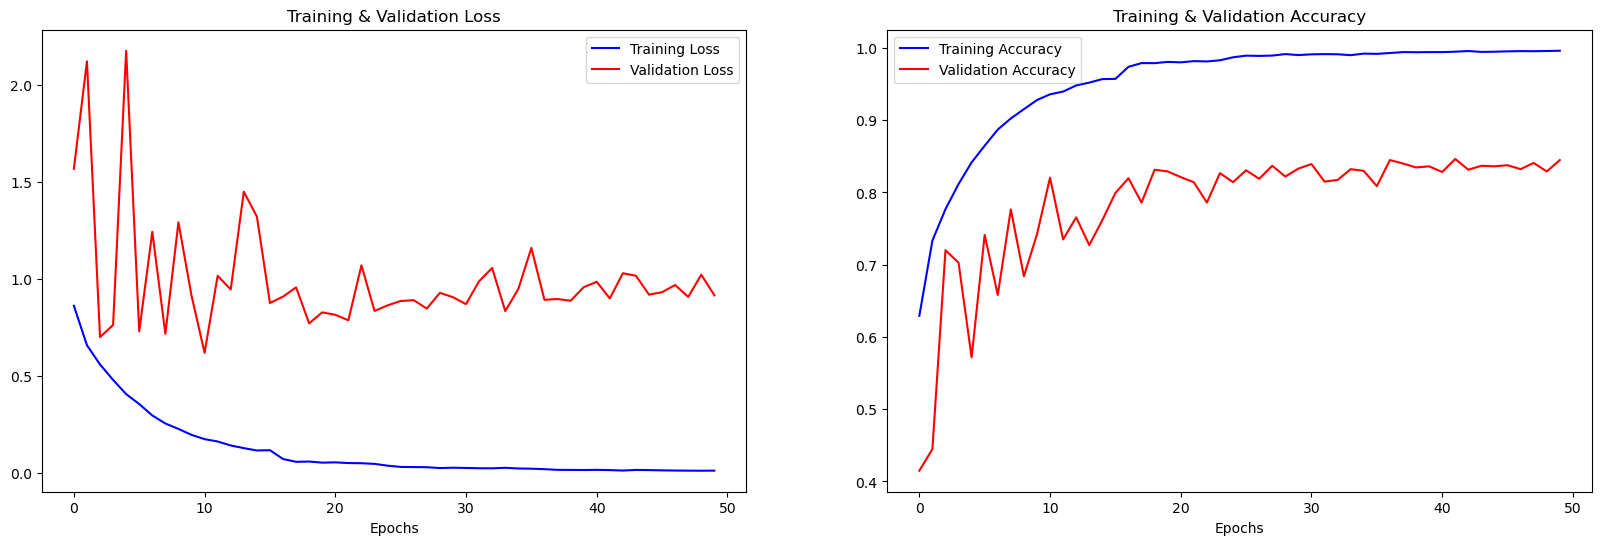

In [9]:
import matplotlib.pyplot as plt


# --- The actual training step ---
history = model.fit(
    x_traincnn, y_train,
    epochs=50,
    validation_data=(x_valcnn, y_val),  # validation set
    batch_size=64,
    callbacks=callbacks,
)


print(" Model has finished training.")


print("Plotting training history...")
epochs = range(len(history.history['accuracy']))
fig, ax = plt.subplots(1, 2, figsize=(20, 6))

# Plotting Loss
ax[0].plot(epochs, history.history['loss'], label='Training Loss', color='blue')
ax[0].plot(epochs, history.history['val_loss'], label='Validation Loss', color='red')
ax[0].set_title('Training & Validation Loss')
ax[0].legend()
ax[0].set_xlabel("Epochs")

# Plotting Accuracy
ax[1].plot(epochs, history.history['accuracy'], label='Training Accuracy', color='blue')
ax[1].plot(epochs, history.history['val_accuracy'], label='Validation Accuracy', color='red')
ax[1].set_title('Training & Validation Accuracy')
ax[1].legend()
ax[1].set_xlabel("Epochs")

plt.show()

In [ ]:
# predicting on test data.
pred_test0 = model.predict(x_testcnn)
y_pred0 = encoder.inverse_transform(pred_test0)
y_test0 = encoder.inverse_transform(y_test)

# Check for random predictions
df0 = pd.DataFrame(columns=['Predicted Labels', 'Actual Labels'])
df0['Predicted Labels'] = y_pred0.flatten()
df0['Actual Labels'] = y_test0.flatten()

df0.head(10)


40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 131ms/step
Test Accuracy (LOCKED holdout): 80.72%


# Evaluation

40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step


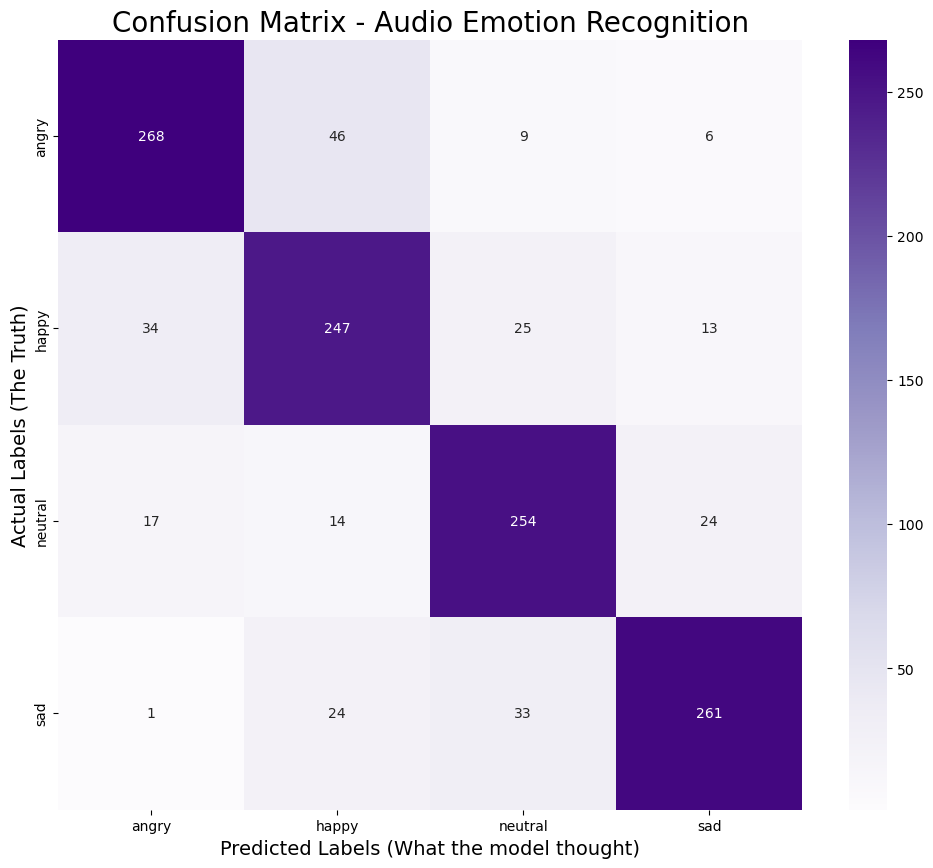


--- Detailed Classification Report ---
              precision    recall  f1-score   support

       angry       0.84      0.81      0.83       329
       happy       0.75      0.77      0.76       319
     neutral       0.79      0.82      0.81       309
         sad       0.86      0.82      0.84       319

    accuracy                           0.81      1276
   macro avg       0.81      0.81      0.81      1276
weighted avg       0.81      0.81      0.81      1276



In [11]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt


pred_test = model.predict(x_testcnn)

y_pred_labels = encoder.inverse_transform(pred_test)
y_test_labels = encoder.inverse_transform(y_test)

cm = confusion_matrix(y_test_labels, y_pred_labels)

labels = encoder.categories_[0]

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=labels, yticklabels=labels)

plt.title('Confusion Matrix - Audio Emotion Recognition', size=20)
plt.xlabel('Predicted Labels (What the model thought)', size=14)
plt.ylabel('Actual Labels (The Truth)', size=14)
plt.show()

print("\n--- Detailed Classification Report ---")
print(classification_report(y_test_labels, y_pred_labels))

# Saving the model

In [15]:
import sys
sys.path.append('src')
import os
import pickle

# Create assets folder 
ASSETS_DIR = 'model_assets'
os.makedirs(ASSETS_DIR, exist_ok=True)

# Create Voxonics_audio directory for placing audio files to analyze
os.makedirs('Voxonics_audio', exist_ok=True)
print("Created 'Voxonics_audio/' — place your .wav files here to analyze.")

# Save model 
model_path = os.path.join(ASSETS_DIR, 'final_emotion_model.keras')
model.save(model_path)
print(f"Model saved to: {model_path}")

# Save encoder
with open(os.path.join(ASSETS_DIR, 'encoder.pickle'), 'wb') as f:
    pickle.dump(encoder, f)

print(f"Assets saved to: {ASSETS_DIR}/")

# ===== Generate Voxonics_Predictions.py in the project root =====
script_content = '''"""
Voxonics Emotion Predictions
==============================
Predicts the emotion of a speaker from a .wav audio file.

HOW TO RUN:
-----------
Single file:
    .venv\\Scripts\\python.exe Voxonics_Predictions.py Voxonics_audio\\your_file.wav

All files in Voxonics_audio folder (PowerShell):
    Get-ChildItem .\\Voxonics_audio\\*.wav | ForEach-Object {
        .venv\\Scripts\\python.exe Voxonics_Predictions.py $_.FullName
    }
"""

import os
import sys
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath(__file__)), "src"))

import pickle
import warnings
import numpy as np
from tensorflow.keras.models import load_model

from audio_pipeline import extract_spectrogram_from_file
from config import MODEL_PATH, ENCODER_PATH

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"


def load_engine():
    print("--- Loading Voxonics Engine ---")
    model = load_model(MODEL_PATH)

    with open(ENCODER_PATH, "rb") as f:
        encoder = pickle.load(f)

    return model, encoder


def predict_emotions_report(audio_path):
    model, encoder = load_engine()

    spec = extract_spectrogram_from_file(audio_path)
    features_cnn = spec[np.newaxis, ..., np.newaxis]  # (1, 128, 128, 1)

    predictions = model.predict(features_cnn, verbose=0)[0]
    emotion_labels = encoder.categories_[0]

    return {label: float(prob * 100) for label, prob in zip(emotion_labels, predictions)}


if __name__ == "__main__":
    test_audio = sys.argv[1] if len(sys.argv) > 1 else "test_voice.wav"

    if os.path.exists(test_audio):
        print(f"Analyzing: {test_audio}")
        results = predict_emotions_report(test_audio)

        print("=" * 40)
        for emotion, confidence in sorted(results.items(), key=lambda x: x[1], reverse=True):
            bar = "█" * int(confidence / 5)
            print(f"{emotion.ljust(12)} | {confidence:6.2f}% {bar}")
        print("=" * 40)
    else:
        print(f"File not found: {test_audio}")
'''

with open("Voxonics_Predictions.py", "w", encoding="utf-8") as f:
    f.write(script_content)

print("Voxonics_Predictions.py created!")


Created 'Voxonics_audio/' — place your .wav files here to analyze.
Model saved to: model_assets\final_emotion_model.keras
Assets saved to: model_assets/
Voxonics_Predictions.py created!
